In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/data.csv", sep=";")

df.columns = df.columns.str.strip()

print(df.shape)

(4424, 37)


In [3]:
early_features = [
    "Marital status",
    "Application mode",
    "Application order",
    "Course",
    "Daytime/evening attendance",
    "Previous qualification",
    "Previous qualification (grade)",
    "Nacionality",
    "Mother's qualification",
    "Father's qualification",
    "Mother's occupation",
    "Father's occupation",
    "Admission grade",
    "Displaced",
    "Educational special needs",
    "Debtor",
    "Tuition fees up to date",
    "Gender",
    "Scholarship holder",
    "Age at enrollment",
    "International",
    "Unemployment rate",
    "Inflation rate",
    "GDP"
]

In [4]:
X = df[early_features]
y = df["Target"]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [6]:
numerical_features = [
    "Previous qualification (grade)",
    "Admission grade",
    "Age at enrollment",
    "Unemployment rate",
    "Inflation rate",
    "GDP"
]

categorical_features = [
    "Marital status",
    "Application mode",
    "Application order",
    "Course",
    "Daytime/evening attendance",
    "Previous qualification",
    "Nacionality",
    "Mother's qualification",
    "Father's qualification",
    "Mother's occupation",
    "Father's occupation",
    "Displaced",
    "Educational special needs",
    "Debtor",
    "Tuition fees up to date",
    "Gender",
    "Scholarship holder",
    "International"
]

In [7]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

In [8]:
## RANDOM FOREST MODEL

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                random_state=42,
                class_weight="balanced"
            )
        )
    ]
)

In [9]:
rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Previous qualification '
                                                   '(grade)',
                                                   'Admission grade',
                                                   'Age at enrollment',
                                                   'Unemployment rate',
                                                   'Inflation rate', 'GDP']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Marital status',
                                                   'Application mode',
                                                   'Application order',
                                                   'Course',
                                                   'Daytime/evening attendance',
                                                   'Previous qualification',
                                                   'Nacionality',
                                                   "Mother's qualification",
                                                   "Father's qualification",
                                                   "Mother's occupation",
                                                   "Father's occupation",
                                                   'Displaced',
                                                   'Educational special needs',
                                                   'Debtor',
                                                   'Tuition fees up to date',
                                                   'Gender',
                                                   'Scholarship holder',
                                                   'International'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=300, random_state=42))])

In [10]:
y_pred_rf = rf_pipeline.predict(X_test)

In [11]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.6406779661016949


In [12]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

     Dropout       0.65      0.62      0.63       284
    Enrolled       0.41      0.11      0.18       159
    Graduate       0.65      0.85      0.74       442

    accuracy                           0.64       885
   macro avg       0.57      0.53      0.52       885
weighted avg       0.61      0.64      0.60       885



In [13]:
rf_report = classification_report(
    y_test,
    y_pred_rf,
    output_dict=True
)

print("Dropout Recall:",
      rf_report["Dropout"]["recall"])

print("Dropout F1:",
      rf_report["Dropout"]["f1-score"])

Dropout Recall: 0.6161971830985915
Dropout F1: 0.6340579710144928


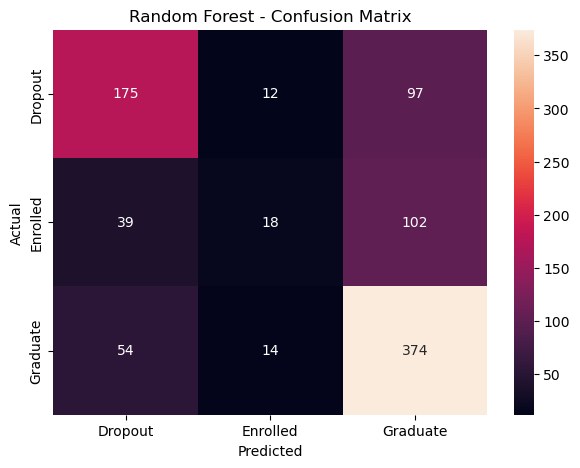

In [14]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    xticklabels=rf_pipeline.classes_,
    yticklabels=rf_pipeline.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest - Confusion Matrix")

plt.show()

In [15]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_lr,
        rf_accuracy
    ],
    "Dropout Recall": [
        report["Dropout"]["recall"],
        rf_report["Dropout"]["recall"]
    ],
    "Dropout F1": [
        report["Dropout"]["f1-score"],
        rf_report["Dropout"]["f1-score"]
    ],
    "Enrolled Recall": [
        report["Enrolled"]["recall"],
        rf_report["Enrolled"]["recall"]
    ],
    "Graduate Recall": [
        report["Graduate"]["recall"],
        rf_report["Graduate"]["recall"]
    ]
})

comparison

NameError: name 'accuracy_lr' is not defined